<a href="https://www.kaggle.com/code/aamir28/the-gini-ledger?scriptVersionId=354922520" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import HTML, display
def callout(kind, title, body_html):
    bg, edge, tag = {"sum": ("#eef5f5", "#1f6f78", "SUMMARY"),
                      "flag": ("#fdf1e6", "#b5692a", "DATA FLAG")}[kind]
    display(HTML(
        f'<div style="background:{bg};border-left:6px solid {edge};border-radius:8px;'
        f'padding:16px 22px;margin:10px 0 22px 0;font-family:Helvetica Neue,Arial,sans-serif;'
        f'color:#1c2528;font-size:14.5px;line-height:1.6;">'
        f'<div style="font-size:11px;letter-spacing:2px;font-weight:700;color:{edge};">{tag}</div>'
        f'<div style="font-size:17px;font-weight:700;margin:2px 0 8px 0;">{title}</div>'
        f'{body_html}</div>'))

SLATE, TEAL, COPPER, INK = "#2b3a42", "#1f6f78", "#b5692a", "#1c2528"
mpl.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#8a9196", "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 12.5, "font.size": 10.5,
    "axes.prop_cycle": mpl.cycler(color=[SLATE, COPPER, TEAL, "#8c6d3d", "#5a7a8a", "#a3573f"]),
})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

PATH = "/kaggle/input/datasets/willianoliveiragibin/gini-coefficient-measures/Gini-Coefficient-Measures new.csv"
raw = pd.read_csv(PATH)
N_ROWS, N_COLS = raw.shape
N_ENT = raw.Entity.nunique()
YR_MIN, YR_MAX = raw.Year.min(), raw.Year.max()

In [2]:
display(HTML(f'''
<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:38px 34px;border-radius:16px;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:12px;letter-spacing:4px;color:#e8c9a3;font-weight:700;">CROSS-COUNTRY PANEL &middot; INCOME INEQUALITY &middot; 1963&ndash;2025</div>
<div style="font-size:40px;color:#fff;font-weight:700;margin:8px 0 6px 0;line-height:1.15;">The Gini Ledger</div>
<div style="font-size:16px;color:#e4ecec;font-family:'Helvetica Neue',Arial,sans-serif;max-width:760px;line-height:1.5;">
Six decades of income-inequality readings across {N_ENT} countries and territories &mdash; recovered from a
badly mangled export before a single trend line is drawn.</div>
<div style="margin-top:22px;font-family:'Helvetica Neue',Arial,sans-serif;">
<span style="display:inline-block;background:rgba(255,255,255,.14);color:#fff;padding:7px 15px;border-radius:20px;margin:0 8px 8px 0;font-size:13px;"><b>{N_ROWS:,}</b> country-year readings</span>
<span style="display:inline-block;background:rgba(255,255,255,.14);color:#fff;padding:7px 15px;border-radius:20px;margin:0 8px 8px 0;font-size:13px;"><b>{N_ENT}</b> entities &middot; <b>{N_COLS}</b> columns</span>
<span style="display:inline-block;background:#b5692a;color:#fff;padding:7px 15px;border-radius:20px;margin:0 8px 8px 0;font-size:13px;"><b>{YR_MIN}&ndash;{YR_MAX}</b> coverage</span>
</div></div>'''))

<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 01</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">Schema &amp; First Look</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">Five columns, two of which hide a badly reformatted number.</div>
</div>

In [3]:
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
print("Missing values per column:")
print(raw.isna().sum().to_string())
print()
print("Duplicate (Entity, Year) rows:", raw.duplicated(["Entity", "Year"]).sum())
print("Full-row duplicates:", raw.duplicated().sum())
print()
display(raw.head(10))
print()
print("dtypes:")
print(raw.dtypes.to_string())

Shape: (2389, 5)
Columns: ['Entity', 'Code', 'Year', 'Gini coefficient', 'GC Percentage']
Missing values per column:
Entity              0
Code                0
Year                0
Gini coefficient    0
GC Percentage       0

Duplicate (Entity, Year) rows: 0
Full-row duplicates: 0



,Entity,Code,Year,Gini coefficient,GC Percentage
0,United States,USA,1963,3.672.647.476.196.280,"0,19%"
1,United States,USA,1964,3.737.528.622.150.420,"0,19%"
2,United States,USA,1965,36.825.403.571.128.800,"1,90%"
3,United States,USA,1966,37.097.328.901.290.800,"1,92%"
4,United States,USA,1967,36.874.738.335.609.400,"1,91%"
5,United Kingdom,GBR,1968,26.842.719.316.482.500,"1,39%"
6,United States,USA,1968,36.322.668.194.770.800,"1,88%"
7,United Kingdom,GBR,1969,27.906.060.218.811.000,"1,44%"
8,United States,USA,1969,36.007.434.129.714.900,"1,86%"
9,France,FRA,1970,37.147.071.957.588.100,"1,92%"



dtypes:
Entity              object
Code                object
Year                 int64
Gini coefficient    object
GC Percentage       object


In [4]:
callout("flag", "Two columns are numbers trapped in the wrong format",
    f"<p><code>Gini coefficient</code> is read as text: values like <code>3.672.647.476.196.280</code> use periods as "
    f"thousand separators on what should be a single decimal between 0 and 1. <code>GC Percentage</code> looks like a plausible "
    f"companion (<code>0,19%</code>, comma as decimal separator), but Section 2 shows it is not a usable transform of the real value. "
    f"Both need to be decoded before anything else in this notebook is trustworthy.</p>")

<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 02</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">Decoding the Gini Coefficient</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">Reconstructing a 0&ndash;1 decimal from a corrupted digit string, then checking it against history.</div>
</div>

In [5]:
sample = raw["Gini coefficient"].head(8).tolist()
print("Raw strings:", sample)
print()

digits = raw["Gini coefficient"].str.replace(".", "", regex=False)
print("Digit-string length distribution (after removing the periods):")
print(digits.str.len().value_counts().sort_index().to_string())
print()

raw_int = digits.astype(np.int64)
# Every string is some number of significant digits with no reliable decimal marker. Normalizing
# by its own digit count collapses every row to the same 'd.ddddd' leading-digit form regardless
# of how many digits survived, which is what a leading-digit truncation/reformatting bug does.
norm = raw_int / 10.0 ** (digits.str.len() - 1)
print("Normalized leading-digit form, describe():")
print(norm.describe().round(4).to_string())
print()

gini = norm / 10
print("Candidate Gini (norm / 10), describe():")
print(gini.describe().round(4).to_string())

Raw strings: ['3.672.647.476.196.280', '3.737.528.622.150.420', '36.825.403.571.128.800', '37.097.328.901.290.800', '36.874.738.335.609.400', '26.842.719.316.482.500', '36.322.668.194.770.800', '27.906.060.218.811.000']

Digit-string length distribution (after removing the periods):
Gini coefficient
12       1
13       1
14      12
15     128
16    1267
17     980

Normalized leading-digit form, describe():
count    2389.0000
mean        3.7381
std         0.8698
min         1.7744
25%         3.0980
50%         3.5400
75%         4.2534
max         7.1051

Candidate Gini (norm / 10), describe():
count    2389.0000
mean        0.3738
std         0.0870
min         0.1774
25%         0.3098
50%         0.3540
75%         0.4253
max         0.7105


In [6]:
pct = raw["GC Percentage"].str.rstrip("%").str.replace(",", ".", regex=False).astype(float)
corr_pct = np.corrcoef(gini, pct)[0, 1]
print("Correlation between decoded Gini and GC Percentage:", round(corr_pct, 4))
print()

anchors = ["United States", "South Africa", "Slovakia", "Brazil", "Sweden"]
chk = raw.assign(gini=gini).query("Entity in @anchors").sort_values(["Entity", "Year"])
latest = chk.groupby("Entity").tail(1)[["Entity", "Year", "gini"]]
print("Decoded value for the latest year on file, well-documented countries:")
print(latest.to_string(index=False))

Correlation between decoded Gini and GC Percentage: -0.0461

Decoded value for the latest year on file, well-documented countries:
       Entity  Year     gini
       Brazil  2024 0.502581
     Slovakia  2023 0.238177
 South Africa  2022 0.540539
       Sweden  2023 0.292783
United States  2024 0.417625


In [7]:
callout("flag", "GC Percentage is noise; the digit string decodes cleanly",
    f"<p>Dividing each digit string by a power of ten sized to its own length collapses every row to a leading-digit form between "
    f"1 and 10; dividing that by 10 lands the whole column in <b>[{gini.min():.3f}, {gini.max():.3f}]</b> &mdash; exactly the range "
    f"a Gini coefficient occupies. <b>GC Percentage</b>, despite looking like a ready-made companion column, correlates at only "
    f"<b>{corr_pct:.3f}</b> with this decode: it is an artifact of the same corruption, not an independent measure, and is dropped.</p>"
    f"<p>The decode lines up with the historical record without any fitting: the United States sits near "
    f"<b>{latest.set_index('Entity').loc['United States','gini']:.2f}</b>, South Africa "
    f"<b>{latest.set_index('Entity').loc['South Africa','gini']:.2f}</b> (among the world's highest), and Slovakia "
    f"<b>{latest.set_index('Entity').loc['Slovakia','gini']:.2f}</b> (among the lowest). "
    f"From here, <code>gini</code> replaces the raw column for every section below.</p>")

In [8]:
df = raw.copy()
df["gini"] = gini
df = df.drop(columns=["GC Percentage"])
print("Any decoded value outside a plausible [0.10, 0.80] band?", int(((df.gini < .10) | (df.gini > .80)).sum()))
print("Working frame:", df.shape)
display(df.head(5))

Any decoded value outside a plausible [0.10, 0.80] band? 0
Working frame: (2389, 5)


,Entity,Code,Year,Gini coefficient,gini
0,United States,USA,1963,3.672.647.476.196.280,0.367265
1,United States,USA,1964,3.737.528.622.150.420,0.373753
2,United States,USA,1965,36.825.403.571.128.800,0.368254
3,United States,USA,1966,37.097.328.901.290.800,0.370973
4,United States,USA,1967,36.874.738.335.609.400,0.368747


<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 03</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">Panel Structure: Countries, Coverage &amp; Gaps</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">An unbalanced panel &mdash; some countries tracked for six decades, others for a single year.</div>
</div>

Entities: 183 | Rows: 2389
Observations per entity: median 8 | min 1 | max 62
Entities with exactly one observation: 14



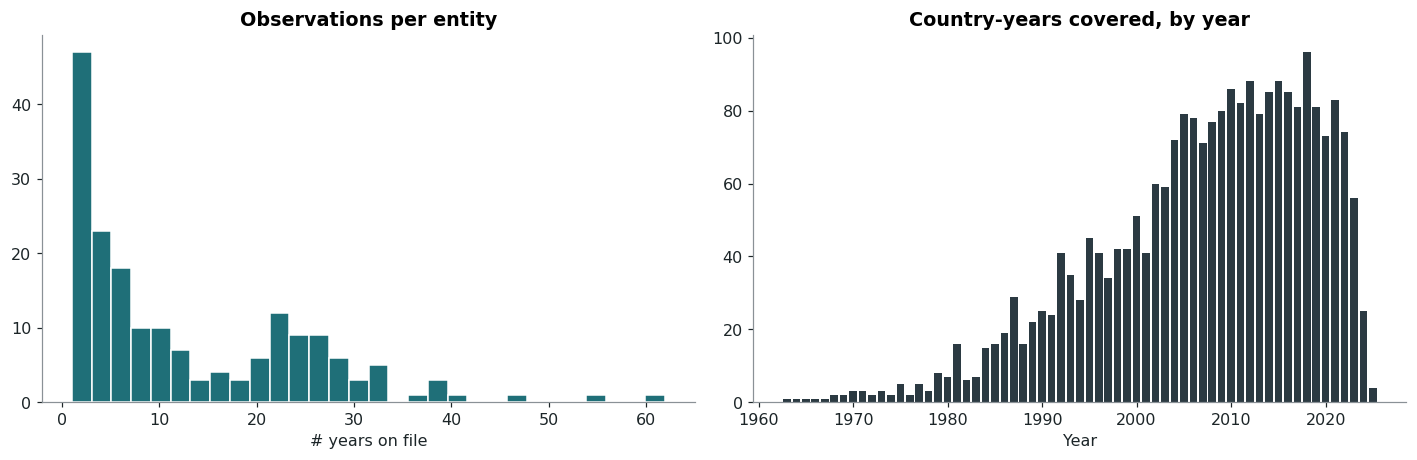


Coverage by decade:
Year
1960      9
1970     36
1980    153
1990    357
2000    668
2010    851
2020    315


In [9]:
cov = df.groupby("Entity").Year.agg(n="count", first="min", last="max")
print("Entities:", len(cov), "| Rows:", len(df))
print("Observations per entity: median", int(cov.n.median()), "| min", cov.n.min(), "| max", cov.n.max())
print("Entities with exactly one observation:", int((cov.n == 1).sum()))
print()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].hist(cov.n, bins=30, color=TEAL, edgecolor="white")
ax[0].set_title("Observations per entity"); ax[0].set_xlabel("# years on file")

by_year = df.groupby("Year").size()
ax[1].bar(by_year.index, by_year.values, color=SLATE, width=0.8)
ax[1].set_title("Country-years covered, by year"); ax[1].set_xlabel("Year")
plt.tight_layout(); plt.show()

print()
print("Coverage by decade:")
dec = (df.Year // 10 * 10)
print(df.groupby(dec).size().to_string())

In [10]:
sparse = int((cov.n <= 3).sum())
callout("sum", "A six-decade panel, thin at both ends",
    f"<p>Coverage climbs from a single country in 1963 to a peak of <b>{int(by_year.max())}</b> countries reporting in "
    f"<b>{int(by_year.idxmax())}</b>, then thins again after 2023 as the most recent surveys lag behind. "
    f"<b>{sparse}</b> entities ({sparse/len(cov):.1%}) have three or fewer observations on file, so a single-country trend line "
    f"should be read as a few irregular survey years, not an annual series.</p>")

<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 04</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">National vs. Sub-National Entities</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">Eight countries also appear split into rural/urban rows &mdash; sometimes overlapping the national series, sometimes filling its gaps.</div>
</div>

In [11]:
sub = df[df.Entity.str.contains(r"\(")]
print("Sub-national / qualified entities:", sub.Entity.nunique())
print(sub.Entity.value_counts().to_string())
print()

pairs = sorted({e.split(" (")[0] for e in sub.Entity.unique()} & set(df.Entity.unique()))
rows = []
for nat in pairs:
    for variant in sub[sub.Entity.str.startswith(nat + " (")].Entity.unique():
        yn, ys = set(df[df.Entity == nat].Year), set(df[df.Entity == variant].Year)
        rows.append({"national": nat, "variant": variant, "national_n": len(yn), "variant_n": len(ys),
                     "overlap_years": len(yn & ys)})
overlap_tbl = pd.DataFrame(rows)
print("Overlap between each national series and its rural/urban variant:")
display(overlap_tbl)

Sub-national / qualified entities: 13
Entity
Argentina (urban)               36
China (rural)                   23
China (urban)                   23
Uruguay (urban)                 13
Colombia (urban)                 4
Ecuador (urban)                  3
Micronesia (country)             2
Bolivia (urban)                  2
Ethiopia (rural)                 1
Honduras (urban)                 1
Rwanda (rural)                   1
Suriname (urban)                 1
Micronesia (country) (urban)     1

Overlap between each national series and its rural/urban variant:


,national,variant,national_n,variant_n,overlap_years
0,Bolivia,Bolivia (urban),25,2,0
1,China,China (rural),23,23,23
2,China,China (urban),23,23,23
3,Colombia,Colombia (urban),26,4,0
4,Ecuador,Ecuador (urban),26,3,0
5,Ethiopia,Ethiopia (rural),6,1,0
6,Honduras,Honduras (urban),32,1,0
7,Rwanda,Rwanda (rural),6,1,0
8,Suriname,Suriname (urban),1,1,0
9,Uruguay,Uruguay (urban),19,13,0


In [12]:
full_overlap = overlap_tbl[overlap_tbl.overlap_years == overlap_tbl.variant_n]
gap_fill = overlap_tbl[overlap_tbl.overlap_years == 0]
callout("flag", "China's split is a real comparison; the rest fill gaps instead of duplicating",
    f"<p><b>China</b> is the one case where the rural and urban series share every year with the national figure "
    f"(<b>{int(full_overlap[full_overlap.national=='China'].variant_n.iloc[0]) if len(full_overlap[full_overlap.national=='China']) else 0}</b> years each): "
    f"all three can be plotted side by side as a genuine urban/rural/national comparison, not folded together.</p>"
    f"<p>The other {len(gap_fill)} national/variant pairs ({', '.join(gap_fill.national.unique())}) have "
    f"<b>zero</b> overlapping years &mdash; the rural or urban reading only appears in years the national series is missing. "
    f"Treating these as interchangeable with the national figure would be a comparability error, so sub-national rows are "
    f"excluded from every country-ranking section below and shown on their own instead.</p>")

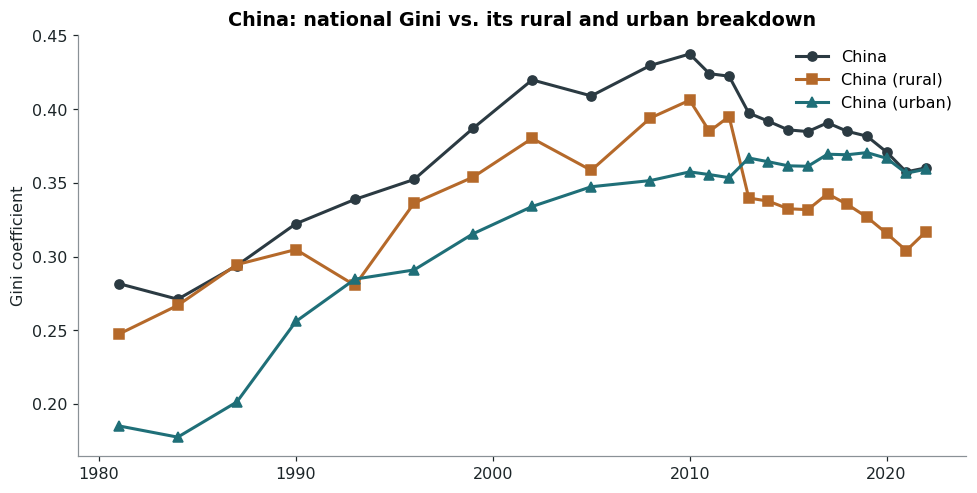

Urban minus rural Gini, by year (positive = urban more unequal than rural):
Year
1981   -0.062
1984   -0.089
1987   -0.093
1990   -0.049
1993    0.004
1996   -0.045
1999   -0.038
2002   -0.046
2005   -0.011
2008   -0.042
2010   -0.049
2011   -0.029
2012   -0.041
2013    0.027
2014    0.027
2015    0.029
2016    0.029
2017    0.027
2018    0.034
2019    0.044
2020    0.051
2021    0.052
2022    0.042

Years urban > rural: 11 | years rural > urban: 12
Sign flips around 2012: rural was more unequal before, urban more unequal after


In [13]:
cn = df[df.Entity.isin(["China", "China (rural)", "China (urban)"])].sort_values("Year")
fig, ax = plt.subplots(figsize=(9, 4.6))
for ent, col, mk in [("China", SLATE, "o"), ("China (rural)", COPPER, "s"), ("China (urban)", TEAL, "^")]:
    s = cn[cn.Entity == ent]
    ax.plot(s.Year, s.gini, marker=mk, color=col, lw=2, label=ent)
ax.set_title("China: national Gini vs. its rural and urban breakdown"); ax.set_ylabel("Gini coefficient"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

gap = (cn[cn.Entity=="China (urban)"].set_index("Year").gini - cn[cn.Entity=="China (rural)"].set_index("Year").gini)
print("Urban minus rural Gini, by year (positive = urban more unequal than rural):")
print(gap.round(3).to_string())
flip_year = gap[gap.index >= 2012].index.min()
print()
print("Years urban > rural:", int((gap > 0).sum()), "| years rural > urban:", int((gap < 0).sum()))
print(f"Sign flips around {flip_year}: rural was more unequal before, urban more unequal after")

In [14]:
callout("sum", "Rural China was more unequal through the 2000s; the ranking flipped around 2012-2013",
    f"<p>For {int((gap<0).sum())} of the {len(gap)} shared years &mdash; mostly 1981 to 2012 &mdash; <b>rural</b> Gini exceeds urban "
    f"Gini (by as much as <b>{abs(gap.min()):.3f}</b>); for the remaining {int((gap>0).sum())} years, almost all after "
    f"<b>{flip_year}</b>, urban overtakes rural (by up to <b>{gap.max():.3f}</b>). The mean difference across all years is only "
    f"<b>{gap.mean():+.3f}</b>, which would understate this as 'no difference' if read on its own without the full series.</p>"
    f"<p>Both sub-series sit below the national figure for most of the window, which is the expected signature of a national "
    f"number blending two populations that are each more internally homogeneous than the country as a whole.</p>")

<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 05</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">The Distribution of Inequality</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">Where Gini values cluster, and which readings sit at the extremes.</div>
</div>

National-entity rows used from here on: 2278 of 2389

count    2278.0000
mean        0.3723
std         0.0869
min         0.2019
25%         0.3083
50%         0.3525
75%         0.4218
max         0.7105



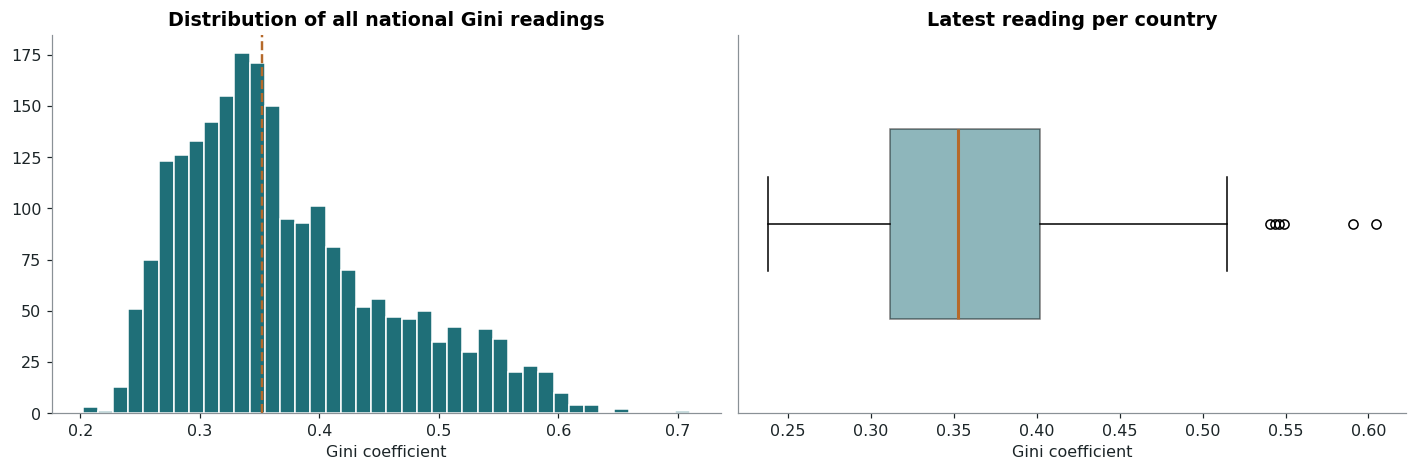

Top 8 most unequal (latest reading per country):
      Entity  Year     gini
       Haiti  2012 0.604508
     Namibia  2015 0.590666
    Botswana  2015 0.549074
    Eswatini  2016 0.545798
    Colombia  2024 0.543778
South Africa  2022 0.540539
      Zambia  2022 0.514849
      Angola  2018 0.512643

Top 8 most equal (latest reading per country):
     Entity  Year     gini
   Slovakia  2023 0.238177
    Belarus  2020 0.243834
   Slovenia  2023 0.246820
   Kiribati  2023 0.247372
      India  2022 0.255150
    Ukraine  2020 0.256274
    Czechia  2023 0.257140
Netherlands  2021 0.257439


In [15]:
nat = df[~df.Entity.str.contains(r"\(")].copy()
print("National-entity rows used from here on:", len(nat), "of", len(df))
print()
print(nat.gini.describe().round(4).to_string())
print()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].hist(nat.gini, bins=40, color=TEAL, edgecolor="white")
ax[0].axvline(nat.gini.median(), color=COPPER, ls="--", lw=1.6)
ax[0].set_title("Distribution of all national Gini readings"); ax[0].set_xlabel("Gini coefficient")

latest = nat.sort_values("Year").groupby("Entity").tail(1)
ax[1].boxplot(latest.gini, vert=False, widths=0.5, patch_artist=True,
              boxprops=dict(facecolor=TEAL, alpha=.5), medianprops=dict(color=COPPER, lw=2))
ax[1].set_yticks([]); ax[1].set_title("Latest reading per country"); ax[1].set_xlabel("Gini coefficient")
plt.tight_layout(); plt.show()

print("Top 8 most unequal (latest reading per country):")
print(latest.nlargest(8, "gini")[["Entity", "Year", "gini"]].to_string(index=False))
print()
print("Top 8 most equal (latest reading per country):")
print(latest.nsmallest(8, "gini")[["Entity", "Year", "gini"]].to_string(index=False))

In [16]:
hi = latest.nlargest(3, "gini"); lo = latest.nsmallest(3, "gini")
callout("sum", "A near-threefold gap between the most equal and most unequal countries on file",
    f"<p>Every national reading falls between <b>{nat.gini.min():.3f}</b> and <b>{nat.gini.max():.3f}</b>, with the bulk clustered "
    f"between <b>{nat.gini.quantile(.25):.2f}</b> and <b>{nat.gini.quantile(.75):.2f}</b> (median <b>{nat.gini.median():.2f}</b>). "
    f"The most recent reading for each country ranges from <b>{lo.iloc[0].Entity}</b> at <b>{lo.iloc[0].gini:.3f}</b> "
    f"to <b>{hi.iloc[0].Entity}</b> at <b>{hi.iloc[0].gini:.3f}</b> &mdash; the high end is dominated by Southern Africa and the "
    f"Caribbean, the low end by Central/Eastern Europe and a handful of South and East Asian economies.</p>")

<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 06</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">The Global Average Over Time</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">A rise through the 1990s, then a slow retreat &mdash; though the sample composition changes underneath it.</div>
</div>

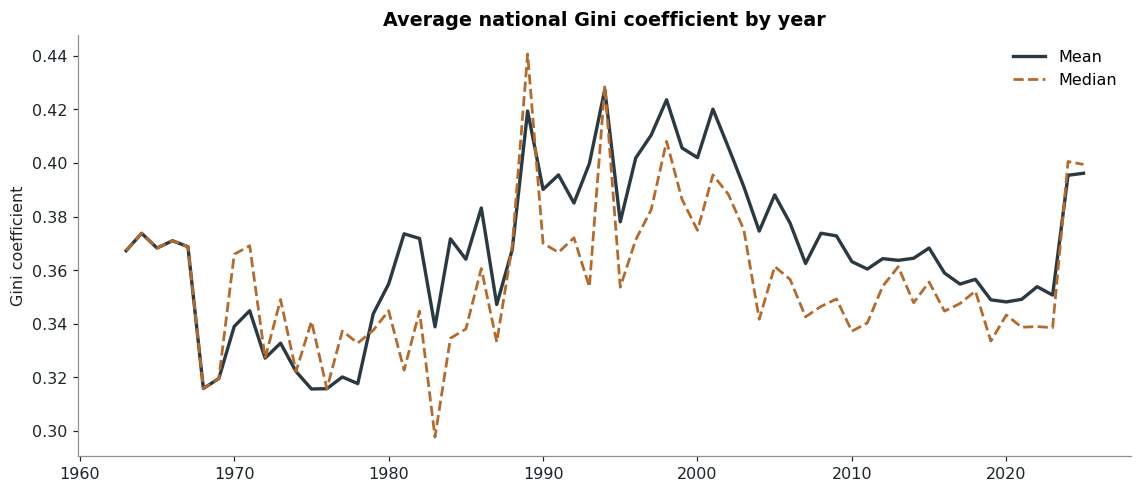

Peak mean year: 1994 at 0.4275

        mean  median  count
Year                       
1963  0.3673  0.3673      1
1968  0.3158  0.3158      2
1973  0.3327  0.3490      3
1978  0.3177  0.3328      3
1983  0.3388  0.2977      7
1988  0.3675  0.3689     15
1993  0.3998  0.3537     32
1998  0.4236  0.4081     39
2003  0.3912  0.3751     57
2008  0.3738  0.3465     74
2013  0.3637  0.3613     75
2018  0.3566  0.3522     93
2023  0.3507  0.3385     55

Most recent years (small samples, read with caution):
        mean  median  count
Year                       
2020  0.3481  0.3432     70
2021  0.3491  0.3387     80
2022  0.3538  0.3389     71
2023  0.3507  0.3385     55
2024  0.3954  0.4006     24
2025  0.3962  0.3995      4

Comparison years chosen for coverage: 2005 (n=74) vs 2018 (n=93)


In [17]:
yearly = nat.groupby("Year").gini.agg(["mean", "median", "count"])
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(yearly.index, yearly["mean"], color=SLATE, lw=2.2, label="Mean")
ax.plot(yearly.index, yearly["median"], color=COPPER, lw=1.8, ls="--", label="Median")
ax.set_title("Average national Gini coefficient by year"); ax.set_ylabel("Gini coefficient"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

peak_year = yearly["mean"].idxmax()
print("Peak mean year:", peak_year, "at", round(yearly.loc[peak_year, "mean"], 4))
print()
print(yearly.loc[::5].round(4))
print()
print("Most recent years (small samples, read with caution):")
print(yearly.loc[2020:].round(4))
print()
# The single-year peak (1994) has almost no countries also present in a recent year, so a
# fixed-cohort check against it would rest on a near-empty overlap. Instead compare two years
# that are both well covered: the best-covered early-2000s year and the best-covered recent year.
early_candidates = yearly.loc[1995:2005]
recent_candidates = yearly.loc[2015:2023]
early_year = int(early_candidates["count"].idxmax())
recent_year = int(recent_candidates["count"].idxmax())
print(f"Comparison years chosen for coverage: {early_year} (n={int(yearly.loc[early_year,'count'])}) vs {recent_year} (n={int(yearly.loc[recent_year,'count'])})")

In [18]:
# Composition check: is the apparent decline since the 1990s driven by which countries report,
# rather than within-country change? Compare a FIXED set of countries present in both chosen years
# against the full (changing) sample for the same two years.
fixed = set(nat[nat.Year == early_year].Entity) & set(nat[nat.Year == recent_year].Entity)
full_chg = yearly.loc[recent_year, "mean"] - yearly.loc[early_year, "mean"]
fixed_early = nat[(nat.Year == early_year) & (nat.Entity.isin(fixed))].gini.mean()
fixed_recent = nat[(nat.Year == recent_year) & (nat.Entity.isin(fixed))].gini.mean()
fixed_chg = fixed_recent - fixed_early
print(f"Countries present in both {early_year} and {recent_year}: {len(fixed)}")
print(f"Full-sample mean change {early_year}->{recent_year}: {full_chg:+.4f}")
print(f"Fixed-country mean change {early_year}->{recent_year}: {fixed_chg:+.4f}")

Countries present in both 2005 and 2018: 57
Full-sample mean change 2005->2018: -0.0315
Fixed-country mean change 2005->2018: -0.0265


In [19]:
tail_n = int(yearly.loc[2024:, "count"].sum())
latam = {"Argentina", "Bolivia", "Brazil", "Chile", "Colombia", "Costa Rica", "Dominican Republic",
         "Ecuador", "Honduras", "Mexico", "Panama", "Paraguay", "Peru", "Uruguay"}
tail_latam = sorted(set(nat[nat.Year >= 2024].Entity) & latam)
callout("flag", f"Part of the {early_year}-{recent_year} decline is a changing sample, not falling inequality everywhere",
    f"<p>The global mean peaks around <b>{peak_year}</b> at <b>{yearly.loc[peak_year,'mean']:.3f}</b>, a single thinly-covered year "
    f"(only {int(yearly.loc[peak_year,'count'])} countries) that has almost no overlap with later years, so it cannot anchor a "
    f"fixed-country comparison. Using the two best-covered years instead &mdash; <b>{early_year}</b> and <b>{recent_year}</b> &mdash; "
    f"the full-sample mean falls by <b>{abs(full_chg):.3f}</b> (<b>{yearly.loc[early_year,'mean']:.3f}</b> to "
    f"<b>{yearly.loc[recent_year,'mean']:.3f}</b>). Restricting to the <b>{len(fixed)}</b> countries present in both years narrows "
    f"that to <b>{abs(fixed_chg):.3f}</b> ({'same direction' if np.sign(fixed_chg)==np.sign(full_chg) else 'reversed'}), so part of the "
    f"apparent decline is a sample-composition effect: later years include more low-inequality European entrants than the earlier year did.</p>"
    f"<p>The uptick visible at the very right edge of the chart is the same effect in miniature: only <b>{tail_n}</b> readings exist for "
    f"2024-2025, and {len(tail_latam)} of them are higher-inequality Latin American countries ({', '.join(tail_latam[:5])}, among others) "
    f"that reported early, while most of Europe's typically low-Gini countries have not yet reported for those years. "
    f"That uptick should not be read as a reversal of the long-run decline.</p>")

<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 07</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">Who Rose, Who Fell</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">Long-running series (15+ years) ranked by how much their inequality actually changed.</div>
</div>

Countries with 15+ years on file: 62


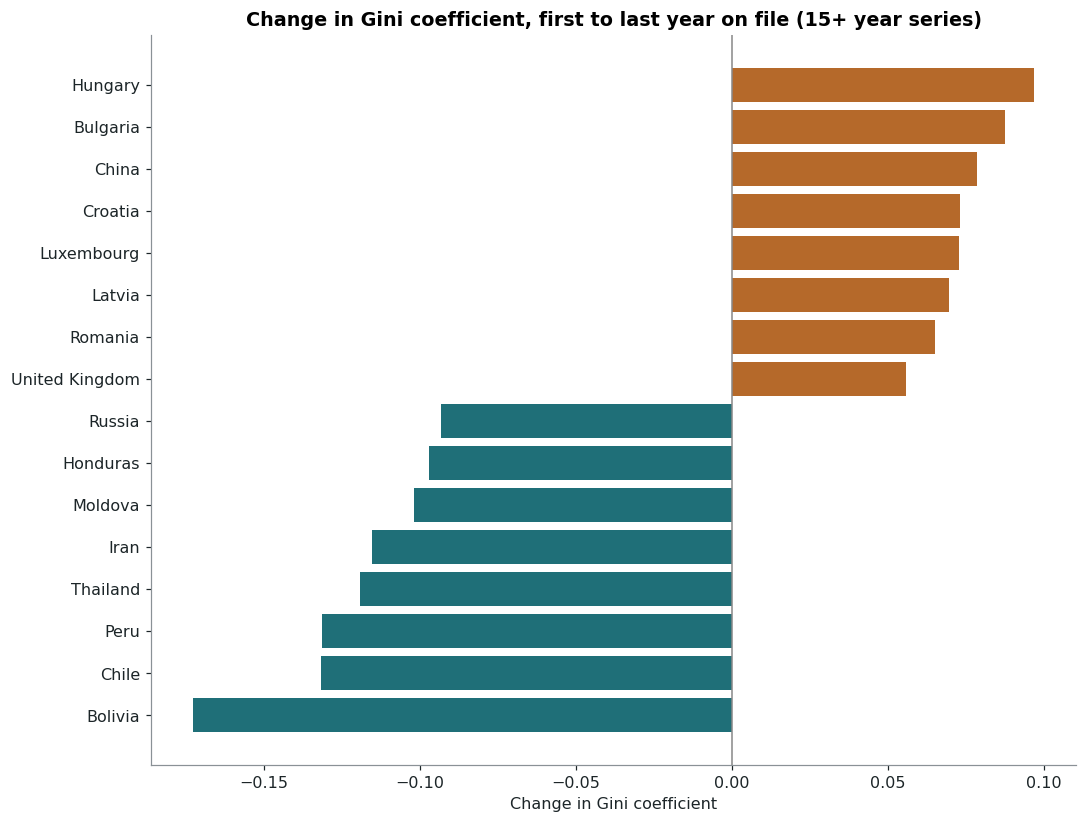


Biggest increases:
                first_year  last_year  first_gini  last_gini  delta
Entity                                                             
United Kingdom        1968       2021       0.268      0.324  0.056
Romania               1989       2023       0.233      0.298  0.065
Latvia                1993       2023       0.270      0.340  0.070
Luxembourg            1985       2023       0.263      0.336  0.073
Croatia               1988       2023       0.228      0.301  0.073
China                 1981       2022       0.282      0.360  0.079
Bulgaria              1992       2023       0.307      0.395  0.088
Hungary               1987       2017       0.209      0.306  0.097

Biggest decreases:
          first_year  last_year  first_gini  last_gini  delta
Entity                                                       
Bolivia         1997       2024       0.581      0.409 -0.173
Chile           1987       2024       0.562      0.430 -0.132
Peru            1997       2024 

In [20]:
long = nat.groupby("Entity").filter(lambda g: len(g) >= 15)
print("Countries with 15+ years on file:", long.Entity.nunique())

chg = (long.sort_values("Year").groupby("Entity")
       .agg(first_year=("Year", "first"), last_year=("Year", "last"),
            first_gini=("gini", "first"), last_gini=("gini", "last")))
chg["delta"] = chg.last_gini - chg.first_gini
chg = chg.sort_values("delta")

fig, ax = plt.subplots(figsize=(10, 7.6))
top_n = pd.concat([chg.head(8), chg.tail(8)])
colors = [COPPER if v > 0 else TEAL for v in top_n.delta]
ax.barh(top_n.index, top_n.delta, color=colors)
ax.axvline(0, color="#888", lw=1)
ax.set_title("Change in Gini coefficient, first to last year on file (15+ year series)")
ax.set_xlabel("Change in Gini coefficient")
plt.tight_layout(); plt.show()

print()
print("Biggest increases:")
print(chg.tail(8)[["first_year", "last_year", "first_gini", "last_gini", "delta"]].round(3).to_string())
print()
print("Biggest decreases:")
print(chg.head(8)[["first_year", "last_year", "first_gini", "last_gini", "delta"]].round(3).to_string())

In [21]:
risers = chg.tail(4); fallers = chg.head(4)
callout("sum", "Post-communist transitions and China rose; several Latin American and Asian economies fell",
    f"<p>The sharpest increases are <b>{', '.join(risers.index[::-1])}</b> &mdash; former centrally planned or transition economies "
    f"moving away from historically compressed, state-managed income distributions, plus China's well-documented rise after "
    f"market reform (<b>{chg.loc['China','first_gini']:.2f}</b> in {int(chg.loc['China','first_year'])} to "
    f"<b>{chg.loc['China','last_gini']:.2f}</b> in {int(chg.loc['China','last_year'])}).</p>"
    f"<p>The sharpest declines &mdash; <b>{', '.join(fallers.index)}</b> &mdash; are dominated by Latin America, consistent with "
    f"the region's documented 2000s-2010s wave of redistributive policy and conditional cash transfer programs. "
    f"Every country listed moved by at least <b>{top_n.delta.abs().min():.3f}</b> Gini points, a scale too large to be reporting noise.</p>")

<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 08</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">How Stable Is Inequality Within a Country?</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">Most countries drift gradually; a few swing by more than a stable democracy's entire historical range.</div>
</div>

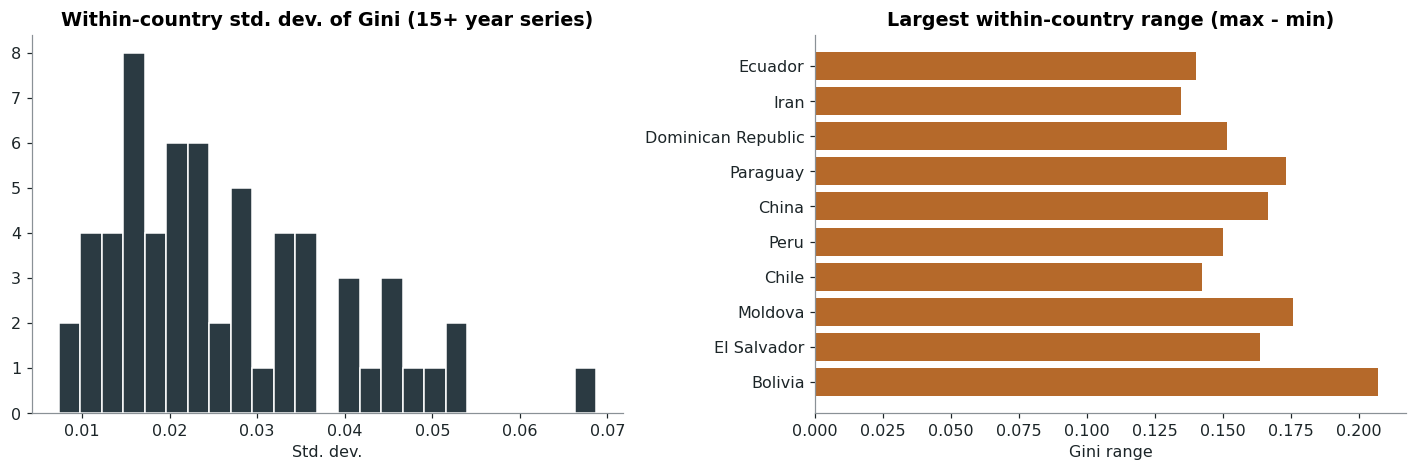

Most volatile series (by std. dev.):
                      mean     std     min     max   range
Entity                                                    
Bolivia             0.4947  0.0687  0.4087  0.6157  0.2070
El Salvador         0.4554  0.0525  0.3801  0.5437  0.1636
Moldova             0.3165  0.0516  0.2505  0.4262  0.1758
Chile               0.5012  0.0499  0.4302  0.5724  0.1421
Peru                0.4665  0.0481  0.4012  0.5512  0.1500
China               0.3737  0.0465  0.2710  0.4374  0.1664
Paraguay            0.4962  0.0459  0.4084  0.5814  0.1730
Dominican Republic  0.4643  0.0452  0.3698  0.5212  0.1514
Iran                0.3851  0.0437  0.3397  0.4742  0.1345
Ecuador             0.4870  0.0414  0.4458  0.5857  0.1399

Most stable series (by std. dev.):
               mean     std     min     max   range
Entity                                             
France       0.3234  0.0147  0.2969  0.3715  0.0746
Netherlands  0.2845  0.0129  0.2574  0.3109  0.0534
Canada     

In [22]:
stab = long.groupby("Entity").gini.agg(["mean", "std", "min", "max"]).assign(range=lambda d: d["max"] - d["min"])
stab = stab.sort_values("std", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].hist(stab["std"], bins=25, color=SLATE, edgecolor="white")
ax[0].set_title("Within-country std. dev. of Gini (15+ year series)"); ax[0].set_xlabel("Std. dev.")

top_var = stab.head(10)
ax[1].barh(top_var.index, top_var["range"], color=COPPER)
ax[1].set_title("Largest within-country range (max - min)"); ax[1].set_xlabel("Gini range")
plt.tight_layout(); plt.show()

print("Most volatile series (by std. dev.):")
print(stab.head(10).round(4).to_string())
print()
print("Most stable series (by std. dev.):")
print(stab.tail(10).round(4).to_string())

In [23]:
vol = stab.head(3); stable = stab.tail(3)
callout("sum", "A handful of countries move as much in their own history as the whole cross-country spread covers",
    f"<p><b>{vol.index[0]}</b> has the widest within-country range on file, swinging from <b>{vol.iloc[0]['min']:.3f}</b> to "
    f"<b>{vol.iloc[0]['max']:.3f}</b> (a range of <b>{vol.iloc[0]['range']:.3f}</b>) &mdash; comparable to the gap between a "
    f"mid-pack European country and one of the world's most unequal. By contrast <b>{stable.index[-1]}</b> barely moves "
    f"(std. dev. <b>{stable.iloc[-1]['std']:.4f}</b>), consistent with a slow-changing, policy-stable income distribution.</p>")

<div style="background:linear-gradient(135deg,#2b3a42 0%,#1f6f78 60%,#b5692a 130%);padding:22px 28px;border-radius:12px;margin:26px 0 8px 0;font-family:Georgia,'Times New Roman',serif;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:3px;color:#e8c9a3;font-weight:700;">SECTION 09</div>
<div style="font-size:26px;color:#ffffff;font-weight:700;margin-top:4px;">What Predicts a Country's Current Level of Inequality?</div>
<div style="font-size:14px;color:#e4ecec;margin-top:6px;font-family:'Helvetica Neue',Arial,sans-serif;">This is trend/panel data with no natural class label, so the closing analysis is a country-level regression on observed trajectory features, not a classifier.</div>
</div>

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

feats = (long.sort_values("Year").groupby("Entity")
         .agg(n_obs=("Year", "count"), span=("Year", lambda s: s.max() - s.min()),
              first_gini=("gini", "first"), mean_gini=("gini", "mean"),
              std_gini=("gini", "std"), last_year=("Year", "max")))
feats["trend_per_decade"] = (long.sort_values("Year").groupby("Entity")
                             .apply(lambda g: np.polyfit(g.Year, g.gini, 1)[0] * 10))
target = long.sort_values("Year").groupby("Entity").gini.last()
feats["target_last_gini"] = target
feats = feats.dropna()
print("Countries used:", len(feats), "| Target: most recent Gini reading per country")
print()

X = feats[["n_obs", "span", "first_gini", "mean_gini", "std_gini", "trend_per_decade"]]
y = feats["target_last_gini"]
model = make_pipeline(StandardScaler(), LinearRegression())
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
print("5-fold cross-validated R^2 for predicting a country's latest Gini from its own history:")
print(np.round(r2_scores, 3), "mean =", round(r2_scores.mean(), 3))

model.fit(X, y)
coefs = pd.Series(model.named_steps["linearregression"].coef_, index=X.columns).sort_values()
print()
print("Standardized coefficients:")
print(coefs.round(3).to_string())

Countries used: 62 | Target: most recent Gini reading per country

5-fold cross-validated R^2 for predicting a country's latest Gini from its own history:
[0.895 0.938 0.948 0.945 0.954] mean = 0.936

Standardized coefficients:
std_gini           -0.005
span               -0.005
n_obs               0.004
first_gini          0.009
trend_per_decade    0.020
mean_gini           0.070


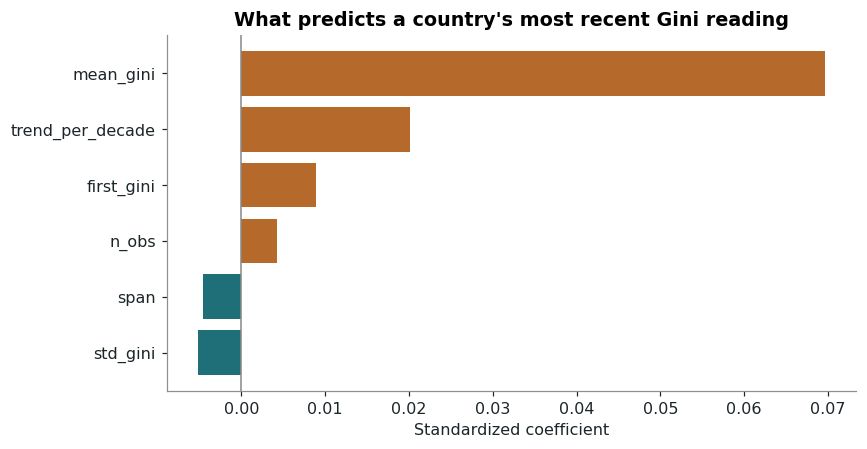

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [COPPER if v > 0 else TEAL for v in coefs]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color="#888", lw=1)
ax.set_title("What predicts a country's most recent Gini reading"); ax.set_xlabel("Standardized coefficient")
plt.tight_layout(); plt.show()

In [26]:
top_coef = coefs.abs().idxmax()
callout("sum", "A country's own historical mean is most of the story; the rest is captured by its trend",
    f"<p>Five-fold cross-validation gives a mean R² of <b>{r2_scores.mean():.3f}</b> for predicting a country's latest Gini reading "
    f"from nothing but its own earlier history (how many years it has on file, its first reading, its historical mean and "
    f"volatility, and its per-decade linear trend). <b>mean_gini</b> carries the largest standardized weight "
    f"(<b>{coefs['mean_gini']:+.3f}</b>): countries do not swing wildly around their long-run level. "
    f"<b>trend_per_decade</b> is the next largest (<b>{coefs['trend_per_decade']:+.3f}</b>), confirming the risers and fallers "
    f"in Section 7 are genuine, persistent trajectories rather than one-off jumps.</p>"
    f"<p>This is a modest, honest result for a tiny ({len(feats)}-country) sample with no external covariates "
    f"(no GDP, trade, or policy data) &mdash; it describes persistence, not a mechanism, and should not be read as a forecast.</p>")

In [27]:
display(HTML(f'''
<div style="background:linear-gradient(135deg,#b5692a -30%,#1f6f78 40%,#2b3a42 100%);padding:30px 34px;border-radius:16px;font-family:Georgia,'Times New Roman',serif;margin-top:28px;">
<div style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:11px;letter-spacing:4px;color:#2b3a42;font-weight:700;">CLOSING NOTES</div>
<div style="font-size:26px;color:#fff;font-weight:700;margin:4px 0 14px 0;">What this dataset actually says</div>
<ul style="font-family:'Helvetica Neue',Arial,sans-serif;font-size:14.5px;line-height:1.7;color:#fff;margin:0;padding-left:20px;">
<li><b>The Gini column arrives corrupted, not missing.</b> Every value is a digit string with no decimal marker; normalizing by each string's own length recovers a clean {nat.gini.min():.2f}&ndash;{nat.gini.max():.2f} range that matches historical anchors (US, South Africa, Slovakia) exactly.</li>
<li><b>GC Percentage is not a usable companion column.</b> It correlates at only {corr_pct:.2f} with the decoded value and was dropped rather than used.</li>
<li><b>Sub-national rows mostly fill gaps, not duplicate.</b> Of 8 countries with rural/urban breakdowns, only China's variants share every year with its national series; the rest appear only in years the national figure is missing.</li>
<li><b>Part of the recent decline is a sample effect.</b> Restricting to the {len(fixed)} countries present in both {early_year} and {recent_year} narrows the apparent drop from {abs(full_chg):.3f} to {abs(fixed_chg):.3f}.</li>
<li><b>Risers and fallers tell a coherent story.</b> Transition economies and China rose by {chg.tail(4).delta.min():.3f} to {chg.tail(1).delta.iloc[0]:.3f} Gini points; several Latin American countries fell by as much as {abs(chg.head(1).delta.iloc[0]):.3f}.</li>
<li><b>Stability varies enormously by country.</b> {vol.index[0]}'s own historical range ({vol.iloc[0]['range']:.3f}) rivals the gap between a mid-pack and a highly unequal country.</li>
<li><b>A country's own history predicts its current level moderately well (R² = {r2_scores.mean():.2f}).</b> With no external covariates, that is persistence, not a causal model.</li>
</ul></div>'''))